In [2]:
import torch
from datasets import load_dataset
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

from transformers_sae import _autoreload
from transformers_sae.ops import MemoryTrackingMode
from transformers_sae.replacement_model import GemmaReplacement, make_replacement_model

# Tweak TRAINING_BATCH_SIZE for your hardware if necessary
if torch.cuda.is_available():
    TRAINING_DEVICE = "cuda:0"
    TRAINING_BATCH_SIZE = 2
elif torch.mps.is_available():
    TRAINING_DEVICE = "mps:0"
    TRAINING_BATCH_SIZE = 2
else:
    TRAINING_DEVICE = "cpu"
    TRAINING_BATCH_SIZE = 2

model_id = "google/gemma-2-2b"
tokenizer = AutoTokenizer.from_pretrained(model_id)
training_dataset = load_dataset(
    "monology/pile-uncopyrighted-parquet",
    split="train",
    streaming=True,
    columns=["text"],
)
validation_dataset = load_dataset(
    "monology/pile-test-val",
    split="validation",
    revision="refs/convert/parquet",
    streaming=True,
    columns=["text"],
)

with MemoryTrackingMode() as mtm:
    model = AutoModelForCausalLM.from_pretrained(
        model_id,
        device_map=TRAINING_DEVICE,
        dtype=torch.bfloat16,
        use_safetensors=True,
        # quantization_config=BitsAndBytesConfig(
        #     load_in_4bit=True, bnb_4bit_compute_dtype=torch.bfloat16
        # ),
    )
    model = make_replacement_model(
        model,
        {},
        num_layers=model.config.num_hidden_layers,
        context_length=1024,  # model.config.max_position_embeddings,
        d_model=model.config.hidden_size,
        layer_path="model.layers",
        replacement_class=GemmaReplacement,
    )

print(model)
print(mtm.memory_max)
print(mtm.memory_cur)

/cloud-dev/.venv/lib/python3.13/site-packages/codefind/registry.py:46: FutureWarning: `torch.distributed.reduce_op` is deprecated, please use `torch.distributed.ReduceOp` instead
  if isinstance(obj, types.FunctionType):


Resolving data files:   0%|          | 0/1987 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/1987 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/288 [00:00<?, ?it/s]

GemmaReplacement(
  (model): Gemma2Model(
    (embed_tokens): Embedding(256000, 2304, padding_idx=0)
    (layers): ModuleList(
      (0-25): 26 x Gemma2DecoderLayer(
        (self_attn): Gemma2Attention(
          (q_proj): Linear(in_features=2304, out_features=2048, bias=False)
          (k_proj): Linear(in_features=2304, out_features=1024, bias=False)
          (v_proj): Linear(in_features=2304, out_features=1024, bias=False)
          (o_proj): Linear(in_features=2048, out_features=2304, bias=False)
        )
        (mlp): Gemma2MLP(
          (gate_proj): Linear(in_features=2304, out_features=9216, bias=False)
          (up_proj): Linear(in_features=2304, out_features=9216, bias=False)
          (down_proj): Linear(in_features=9216, out_features=2304, bias=False)
          (act_fn): GELUTanh()
        )
        (input_layernorm): Gemma2RMSNorm((2304,), eps=1e-06)
        (post_attention_layernorm): Gemma2RMSNorm((2304,), eps=1e-06)
        (pre_feedforward_layernorm): Gemma2RMSNor

In [3]:
TRAINING_CACHE_DIR = None if torch.cuda.is_available() else ".training_cache"
VALIDATION_CACHE_DIR = None if torch.cuda.is_available() else ".validation_cache"
NUM_TRAINING_TOKENS = int(1e7) if torch.cuda.is_available() else int(1e6)
EVAL_INTERVAL = int(1e5)
NUM_VALIDATION_TOKENS = int(1e6) if torch.cuda.is_available() else int(1e5)
D_SAE = model.d_model * 4
TOPK = 100
TOKENIZER_BATCH_SIZE = 128
FINETUNE_FRACTION = 0.1
# Note this will use up ~1.8GB of space, set to False if you want to skip
SAVE_FINAL_RESULTS = True

In [4]:
from transformers_sae.ops import find_latest_checkpoint, load_checkpoint

checkpoint_dir = "/workspace/sae_checkpoints/gemma_2_2b/next_layer/"

saes = {}

# Load the latest checkpoints for each layer
for layer in range(model.num_layers - 1, -1, -1):
    checkpoint = find_latest_checkpoint(checkpoint_dir, layer)
    if checkpoint is not None:
        saes[layer] = load_checkpoint(checkpoint).sae
        saes[layer].onload()
        print(f"Loaded checkpoint for layer {layer}")
        break
    else:
        print(f"No checkpoint found for layer {layer}")
        # raise ValueError(f"No checkpoint found for layer {layer}")


Loaded checkpoint for layer 25


In [5]:
from transformers_sae.validation import run_validations

validations = run_validations(
    model,
    tokenizer,
    saes,
    validation_dataset,
    TOKENIZER_BATCH_SIZE,
    TRAINING_BATCH_SIZE,
    NUM_VALIDATION_TOKENS,
    cache_dir=VALIDATION_CACHE_DIR,
    start_layer=25
)

Running SAE evals:   0%|          | 0/1000000 [00:00<?, ?it/s]

In [71]:
from transformers_sae.ops import load_training_result

checkpoint_dir = "/workspace/sae_checkpoints/gemma_2_2b/next_layer/"
training_results = load_training_result(checkpoint_dir, {25})

Running SAE evals:   0%|          | 0/1000000 [00:00<?, ?it/s]

Running SAE evals:   0%|          | 0/1000000 [00:00<?, ?it/s]

KeyboardInterrupt: 

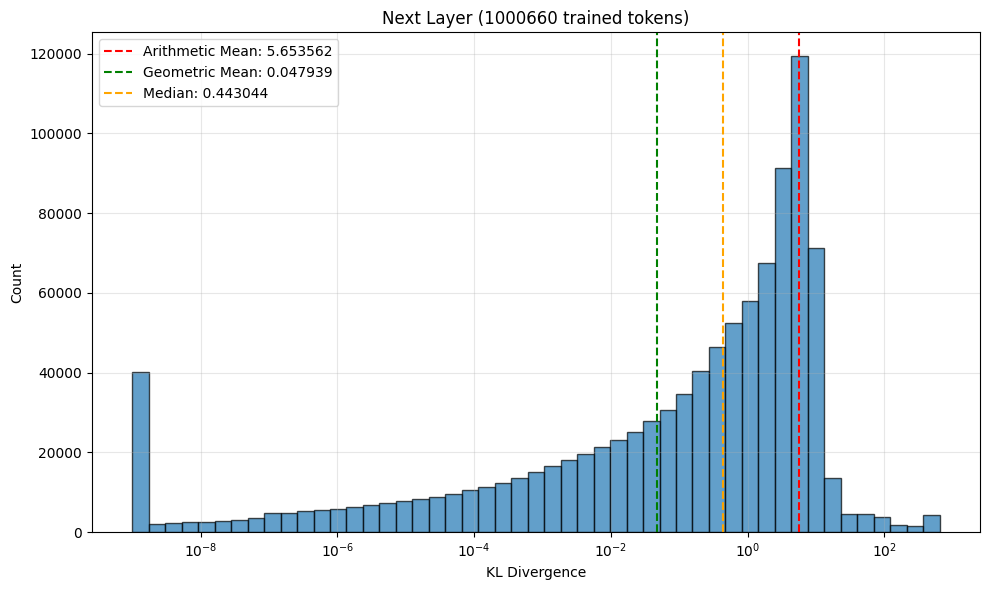

In [ ]:
# Try to see KL scaling

import matplotlib.pyplot as plt
import numpy as np

geo_means = []

for checkpoint in training_results[25]:
    validations = run_validations(
        model,
        tokenizer,
        saes,
        validation_dataset,
        TOKENIZER_BATCH_SIZE,
        TRAINING_BATCH_SIZE,
        NUM_VALIDATION_TOKENS,
        cache_dir=VALIDATION_CACHE_DIR,
        start_layer=25,
    )

    kl = validations.layer_results[26].kl.astype(np.float32)
    kl = np.clip(kl, 1e-9, None)

    fig, ax = plt.subplots(figsize=(10, 6))

    # Create histogram of KL values with log-scaled x-axis
    ax.hist(
        kl,
        bins=np.logspace(np.log10(kl.min()), np.log10(kl.max()), 50),
        alpha=0.7,
        edgecolor="black",
    )
    ax.set_xscale("log")
    ax.set_xlabel("KL Divergence")
    ax.set_ylabel("Count")
    ax.set_title(f"Next Layer ({checkpoint.total_tokens_trained} trained tokens)")
    ax.grid(True, alpha=0.3)

    # Add statistics
    arithmetic_mean = np.mean(kl)
    geometric_mean = np.exp(np.mean(np.log(kl)))
    log_std = np.std(np.log(kl))
    gsd = np.exp(log_std)
    median_kl = np.median(kl)

    geo_means.append((checkpoint.total_tokens_trained, geometric_mean, gsd))
    print(geo_means)

    ax.axvline(
        arithmetic_mean,
        color="red",
        linestyle="--",
        label=f"Arithmetic Mean: {arithmetic_mean:.6f}",
    )
    ax.axvline(
        geometric_mean,
        color="green",
        linestyle="--",
        label=f"Geometric Mean: {geometric_mean:.6f}",
    )
    ax.axvline(
        median_kl, color="orange", linestyle="--", label=f"Median: {median_kl:.6f}"
    )
    ax.legend()

    plt.tight_layout()
    plt.show()

print(geo_means)

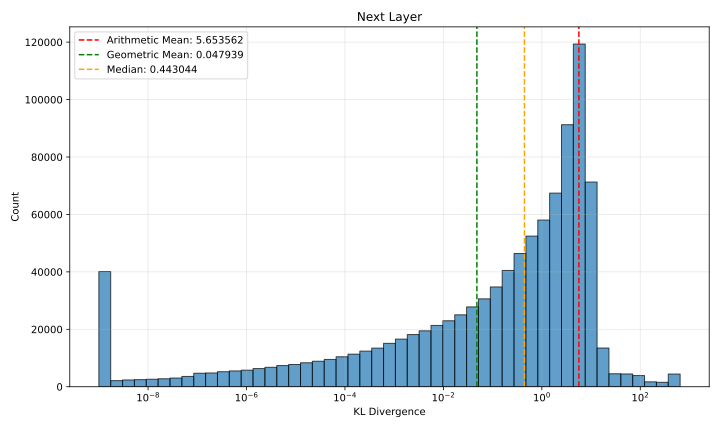

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

from transformers_sae.ops import current_plot_to_svg

kl = validations.layer_results[26].kl.astype(np.float32)
kl = np.clip(kl, 1e-9, None)

fig, ax = plt.subplots(figsize=(10, 6))

# Create histogram of KL values with log-scaled x-axis
ax.hist(
    kl,
    bins=np.logspace(np.log10(kl.min()), np.log10(kl.max()), 50),
    alpha=0.7,
    edgecolor="black",
)
ax.set_xscale("log")
ax.set_xlabel("KL Divergence")
ax.set_ylabel("Count")
ax.set_title("Next Layer")
ax.grid(True, alpha=0.3)

# Add statistics
arithmetic_mean = np.mean(kl)
geometric_mean = np.exp(np.mean(np.log(kl)))
median_kl = np.median(kl)

ax.axvline(
    arithmetic_mean,
    color="red",
    linestyle="--",
    label=f"Arithmetic Mean: {arithmetic_mean:.6f}",
)
ax.axvline(
    geometric_mean,
    color="green",
    linestyle="--",
    label=f"Geometric Mean: {geometric_mean:.6f}",
)
ax.axvline(median_kl, color="orange", linestyle="--", label=f"Median: {median_kl:.6f}")
ax.legend()

plt.tight_layout()
current_plot_to_svg("layer_25_kl_dist")

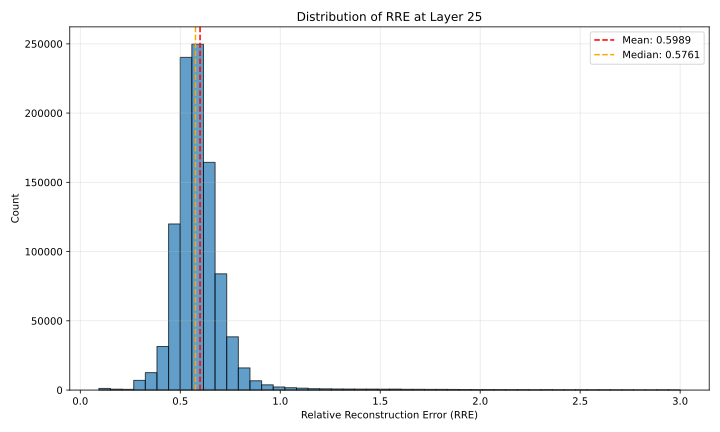

In [25]:
rre_values = validations.layer_results[25].rre.astype(np.float32)
rre_values = rre_values[rre_values < 3]

fig, ax = plt.subplots(figsize=(10, 6))

# Create histogram of RRE values
ax.hist(rre_values, bins=50, alpha=0.7, edgecolor="black")
ax.set_xlabel("Relative Reconstruction Error (RRE)")
ax.set_ylabel("Count")
ax.set_title("Distribution of RRE at Layer 25")
ax.grid(True, alpha=0.3)

# Add statistics
mean_rre = np.mean(rre_values)
median_rre = np.median(rre_values)

ax.axvline(mean_rre, color="red", linestyle="--", label=f"Mean: {mean_rre:.4f}")
ax.axvline(
    median_rre, color="orange", linestyle="--", label=f"Median: {median_rre:.4f}"
)
ax.legend()

plt.tight_layout()
current_plot_to_svg("layer_25_rre_dist")

In [11]:
sum(validations.layer_results[25].live_features) / len(validations.layer_results[25].live_features)

0.77392578125

In [43]:
from transformers_sae.sae_lens_wrapper import wrap_sae_lens_pretrained

gemma_scope = wrap_sae_lens_pretrained(
    release="gemma-scope-2b-pt-res-canonical",
    sae_id="layer_25/width_16k/canonical",
    device=TRAINING_DEVICE,
)

In [47]:
from transformers_sae.validation import run_validations

gemma_scope_validations = run_validations(
    model,
    tokenizer,
    {25: gemma_scope},
    validation_dataset,
    TOKENIZER_BATCH_SIZE,
    TRAINING_BATCH_SIZE,
    NUM_VALIDATION_TOKENS,
    cache_dir=VALIDATION_CACHE_DIR,
    start_layer=25
)

Running SAE evals:   0%|          | 0/1000000 [00:00<?, ?it/s]

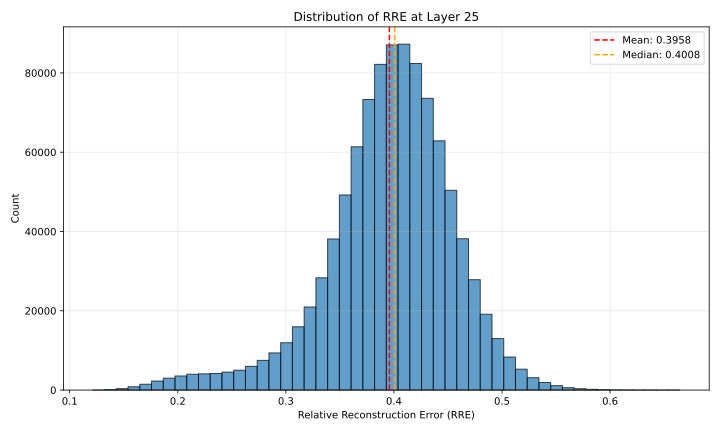

In [49]:
rre_values = gemma_scope_validations.layer_results[25].rre.astype(np.float32)

fig, ax = plt.subplots(figsize=(10, 6))

# Create histogram of RRE values
ax.hist(rre_values, bins=50, alpha=0.7, edgecolor="black")
ax.set_xlabel("Relative Reconstruction Error (RRE)")
ax.set_ylabel("Count")
ax.set_title("Distribution of RRE at Layer 25")
ax.grid(True, alpha=0.3)

# Add statistics
mean_rre = np.mean(rre_values)
median_rre = np.median(rre_values)

ax.axvline(mean_rre, color="red", linestyle="--", label=f"Mean: {mean_rre:.4f}")
ax.axvline(
    median_rre, color="orange", linestyle="--", label=f"Median: {median_rre:.4f}"
)
ax.legend()

plt.tight_layout()
current_plot_to_svg("layer_25_rre_dist")

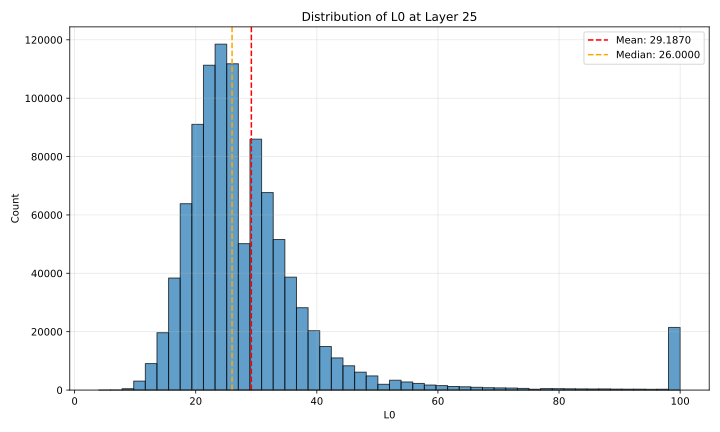

In [21]:
l0 = validations.layer_results[25].l0.astype(np.float32)

fig, ax = plt.subplots(figsize=(10, 6))

# Create histogram of L0 values
ax.hist(l0, bins=50, alpha=0.7, edgecolor="black")
ax.set_xlabel("L0")
ax.set_ylabel("Count")
ax.set_title("Distribution of L0 at Layer 25")
ax.grid(True, alpha=0.3)

# Add statistics
mean_rre = np.mean(l0)
median_rre = np.median(l0)

ax.axvline(mean_rre, color="red", linestyle="--", label=f"Mean: {mean_rre:.4f}")
ax.axvline(
    median_rre, color="orange", linestyle="--", label=f"Median: {median_rre:.4f}"
)
ax.legend()

plt.tight_layout()
current_plot_to_svg("layer_25_rre_dist")

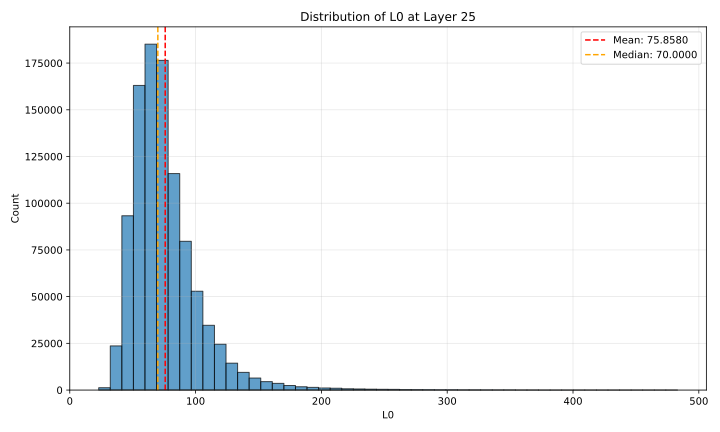

In [50]:
l0 = gemma_scope_validations.layer_results[25].l0.astype(np.float32)

fig, ax = plt.subplots(figsize=(10, 6))

# Create histogram of L0 values
ax.hist(l0, bins=50, alpha=0.7, edgecolor="black")
ax.set_xlabel("L0")
ax.set_ylabel("Count")
ax.set_title("Distribution of L0 at Layer 25")
ax.grid(True, alpha=0.3)

# Add statistics
mean_rre = np.mean(l0)
median_rre = np.median(l0)

ax.axvline(mean_rre, color="red", linestyle="--", label=f"Mean: {mean_rre:.4f}")
ax.axvline(
    median_rre, color="orange", linestyle="--", label=f"Median: {median_rre:.4f}"
)
ax.legend()

plt.tight_layout()
current_plot_to_svg("layer_25_rre_dist")

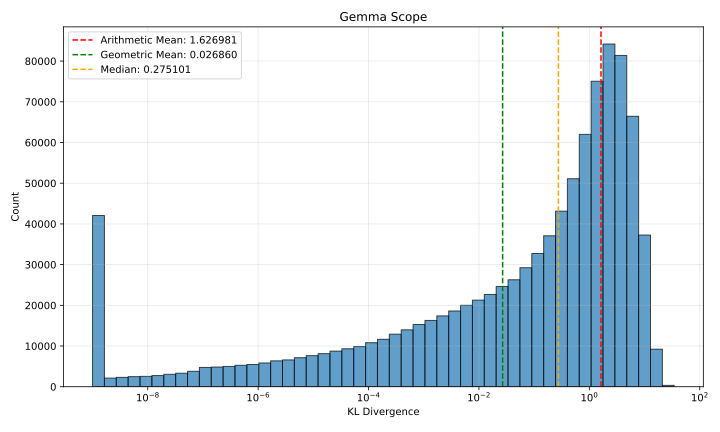

In [70]:
kl = gemma_scope_validations.layer_results[26].kl.astype(np.float32)
kl = np.clip(kl, 1e-9, None)

fig, ax = plt.subplots(figsize=(10, 6))

# Create histogram of KL values with log-scaled x-axis
ax.hist(kl, bins=np.logspace(np.log10(kl.min()), np.log10(kl.max()), 50), alpha=0.7, edgecolor="black")
ax.set_xscale("log")
ax.set_xlabel("KL Divergence")
ax.set_ylabel("Count")
ax.set_title("Gemma Scope")
ax.grid(True, alpha=0.3)

# Add statistics
arithmetic_mean = np.mean(kl)
geometric_mean = np.exp(np.mean(np.log(kl)))
median_kl = np.median(kl)

ax.axvline(arithmetic_mean, color="red", linestyle="--", label=f"Arithmetic Mean: {arithmetic_mean:.6f}")
ax.axvline(geometric_mean, color="green", linestyle="--", label=f"Geometric Mean: {geometric_mean:.6f}")
ax.axvline(median_kl, color="orange", linestyle="--", label=f"Median: {median_kl:.6f}")
ax.legend()

plt.tight_layout()
current_plot_to_svg("layer_25_kl_dist")

In [44]:
from transformers_sae.validation import generate_with_replacement

with torch.autocast(
    device_type="cuda" if model.device.type == "cuda" else "cpu",
    dtype=torch.bfloat16,
):
    generate_with_replacement(
        model,
        tokenizer,
        "The capital of France",
        {25: gemma_scope},
        # {},
        # {layer: sae for layer, sae in saes.items() if layer > 24},
    )

is a city that is full of history and culture. It is also a city that is home to some of the world’s most famous museums and museums. The Museum of the French Republic is one of the most popular museums in the city. It is a museum that is located in the city center and it is a place that is home to a variety of exhibits. The museum is a place that is home to a variety of exhibits that are all related to the history of the French Republic. The
